# ============================================================
# PROJETO: Análise Exploratória e Estatística de Dados
# ============================================================

In [1]:
# Instalar pacotes necessários
!pip install pandas numpy matplotlib seaborn scipy statsmodels


[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:

# 1. Importação de bibliotecas
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [5]:
# 2. Carregamento dos dados
df = pd.read_csv("vendas_supermercado_com_cliente.csv")

In [11]:
# Visualização inicial
print(df.head())
print(df.info())
print(df.describe())

         Data   Produto          Categoria  Preço  Quantidade  Desconto  \
0  2023-01-01     Maçãs  Alimentos Frescos  16.46          10       0.0   
1  2023-01-01   Bananas  Alimentos Frescos   2.39           4       0.0   
2  2023-01-01  Laranjas  Alimentos Frescos   8.38           5       0.0   
3  2023-01-01   Tomates  Alimentos Frescos   2.03          15       0.0   
4  2023-01-01    Alface  Alimentos Frescos  37.14          14       0.0   

   Total_Venda  Idade    Renda  valor_total  
0       164.60     49  2715.61       164.60  
1         9.56     29  2280.15         9.56  
2        41.90     67  4419.56        41.90  
3        30.45     29  3809.17        30.45  
4       519.96     24  1013.42       519.96  
<class 'pandas.DataFrame'>
RangeIndex: 20075 entries, 0 to 20074
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Data         20075 non-null  str    
 1   Produto      20075 non-null  str    
 2   Ca

In [12]:
# ============================================================
# 4. Verificação de qualidade dos dados
# ============================================================

# Verificar valores nulos
print("Valores nulos por coluna:")
print(df.isnull().sum())

# Verificar duplicidades
duplicados = df.duplicated().sum()
print(f"Número de linhas duplicadas: {duplicados}")

# Visualizar as duplicadas:
df[df.duplicated()]

Valores nulos por coluna:
Data           0
Produto        0
Categoria      0
Preço          0
Quantidade     0
Desconto       0
Total_Venda    0
Idade          0
Renda          0
valor_total    0
dtype: int64
Número de linhas duplicadas: 0


,Data,Produto,Categoria,Preço,Quantidade,Desconto,Total_Venda,Idade,Renda,valor_total


In [13]:
# ============================================================
# 5. Ajuste do tipo da coluna 'data'
# ============================================================

# Converter a coluna 'data' para datetime
df['Data'] = pd.to_datetime(df['Data'], errors='coerce')

# Verificar se houve algum problema na conversão
print(df['Data'].head())
print(df['Data'].dtypes)


# Criar colunas derivadas para análises
df['ano'] = df['Data'].dt.year
df['mes'] = df['Data'].dt.month
df['dia'] = df['Data'].dt.day
df['dia_semana'] = df['Data'].dt.day_name()

0   2023-01-01
1   2023-01-01
2   2023-01-01
3   2023-01-01
4   2023-01-01
Name: Data, dtype: datetime64[us]
datetime64[us]


In [14]:
# Visualização após inclusão das colunas
print(df.head())
print(df.info())
print(df.describe())

        Data   Produto          Categoria  Preço  Quantidade  Desconto  \
0 2023-01-01     Maçãs  Alimentos Frescos  16.46          10       0.0   
1 2023-01-01   Bananas  Alimentos Frescos   2.39           4       0.0   
2 2023-01-01  Laranjas  Alimentos Frescos   8.38           5       0.0   
3 2023-01-01   Tomates  Alimentos Frescos   2.03          15       0.0   
4 2023-01-01    Alface  Alimentos Frescos  37.14          14       0.0   

   Total_Venda  Idade    Renda  valor_total   ano  mes  dia dia_semana  
0       164.60     49  2715.61       164.60  2023    1    1     Sunday  
1         9.56     29  2280.15         9.56  2023    1    1     Sunday  
2        41.90     67  4419.56        41.90  2023    1    1     Sunday  
3        30.45     29  3809.17        30.45  2023    1    1     Sunday  
4       519.96     24  1013.42       519.96  2023    1    1     Sunday  
<class 'pandas.DataFrame'>
RangeIndex: 20075 entries, 0 to 20074
Data columns (total 14 columns):
 #   Column       N

In [15]:
# Categorizar Idade
def categorizar_idade(idade):
    if 18 <= idade <= 35: return 'Jovem (18-35)'
    elif 36 <= idade <= 59: return 'Adulto (36-59)'
    else: return 'Idoso (60+)'

df['Faixa_Etaria'] = df['Idade'].apply(categorizar_idade)
df['Tem_Desconto'] = df['Desconto'] > 0

In [16]:
# Visualização após categorização
print(df.head())
print(df.info())
print(df.describe())

        Data   Produto          Categoria  Preço  Quantidade  Desconto  \
0 2023-01-01     Maçãs  Alimentos Frescos  16.46          10       0.0   
1 2023-01-01   Bananas  Alimentos Frescos   2.39           4       0.0   
2 2023-01-01  Laranjas  Alimentos Frescos   8.38           5       0.0   
3 2023-01-01   Tomates  Alimentos Frescos   2.03          15       0.0   
4 2023-01-01    Alface  Alimentos Frescos  37.14          14       0.0   

   Total_Venda  Idade    Renda  valor_total   ano  mes  dia dia_semana  \
0       164.60     49  2715.61       164.60  2023    1    1     Sunday   
1         9.56     29  2280.15         9.56  2023    1    1     Sunday   
2        41.90     67  4419.56        41.90  2023    1    1     Sunday   
3        30.45     29  3809.17        30.45  2023    1    1     Sunday   
4       519.96     24  1013.42       519.96  2023    1    1     Sunday   

     Faixa_Etaria  Tem_Desconto  
0  Adulto (36-59)         False  
1   Jovem (18-35)         False  
2     Id

In [8]:
# Criar colunas derivadas
df["valor_total"] = df["Preço"] * df["Quantidade"] - df["Desconto"]

In [12]:
# Visualização após coluna derivada
print(df.head())
print(df.info())
print(df.describe())

        Data   Produto          Categoria  Preço  Quantidade  Desconto  \
0 2023-01-01     Maçãs  Alimentos Frescos  16.46          10       0.0   
1 2023-01-01   Bananas  Alimentos Frescos   2.39           4       0.0   
2 2023-01-01  Laranjas  Alimentos Frescos   8.38           5       0.0   
3 2023-01-01   Tomates  Alimentos Frescos   2.03          15       0.0   
4 2023-01-01    Alface  Alimentos Frescos  37.14          14       0.0   

   Total_Venda  Idade    Renda   ano  mes  dia dia_semana    Faixa_Etaria  \
0       164.60     49  2715.61  2023    1    1     Sunday  Adulto (36-59)   
1         9.56     29  2280.15  2023    1    1     Sunday   Jovem (18-35)   
2        41.90     67  4419.56  2023    1    1     Sunday     Idoso (60+)   
3        30.45     29  3809.17  2023    1    1     Sunday   Jovem (18-35)   
4       519.96     24  1013.42  2023    1    1     Sunday   Jovem (18-35)   

   Tem_Desconto  valor_total  
0         False       164.60  
1         False         9.56  

Estatística Descritiva

In [14]:
# Função para calcular medidas
def resumo_estatistico(serie):
    return {
        "média": serie.mean(),
        "mediana": serie.median(),
        "moda": serie.mode()[0],
        "desvio_padrão": serie.std(),
        "variância": serie.var(),
        "amplitude": serie.max() - serie.min(),
        "coef_variação": serie.std()/serie.mean()
    }

variaveis = ["Preço","Quantidade","Desconto","valor_total","Idade","Renda"]

for var in variaveis:
    print(f"\n--- {var.upper()} ---")
    print(resumo_estatistico(df[var]))


--- PREÇO ---
{'média': np.float64(25.57710933997509), 'mediana': np.float64(25.66), 'moda': np.float64(10.58), 'desvio_padrão': np.float64(14.115988249781115), 'variância': np.float64(199.26112426795848), 'amplitude': np.float64(48.99), 'coef_variação': np.float64(0.5518992808041404)}

--- QUANTIDADE ---
{'média': np.float64(10.007671232876712), 'mediana': np.float64(10.0), 'moda': np.int64(6), 'desvio_padrão': np.float64(5.488450192458794), 'variância': np.float64(30.12308551510098), 'amplitude': np.int64(18), 'coef_variação': np.float64(0.5484243101860107)}

--- DESCONTO ---
{'média': np.float64(0.039760398505603985), 'mediana': np.float64(0.0), 'moda': np.float64(0.0), 'desvio_padrão': np.float64(0.08501098731559598), 'variância': np.float64(0.007226867964372421), 'amplitude': np.float64(0.5), 'coef_variação': np.float64(2.1380818731888263)}

--- VALOR_TOTAL ---
{'média': np.float64(256.00537484433374), 'mediana': np.float64(194.16), 'moda': np.float64(15.66), 'desvio_padrão': np.


Quartis de Preço:
0.25    13.26
0.50    25.66
0.75    37.77
Name: Preço, dtype: float64
Percentil 90: 45.04

Quartis de Quantidade:
0.25     5.0
0.50    10.0
0.75    15.0
Name: Quantidade, dtype: float64
Percentil 90: 18.0

Quartis de Desconto:
0.25    0.0
0.50    0.0
0.75    0.0
Name: Desconto, dtype: float64
Percentil 90: 0.19

Quartis de valor_total:
0.25     80.07
0.50    194.16
0.75    385.47
Name: valor_total, dtype: float64
Percentil 90: 583.6140000000003

Quartis de Idade:
0.25    32.0
0.50    46.0
0.75    60.0
Name: Idade, dtype: float64
Percentil 90: 69.0

Quartis de Renda:
0.25    1993.625
0.50    2998.830
0.75    4007.675
Name: Renda, dtype: float64
Percentil 90: 4601.298000000001
Preço: 0 outliers detectados


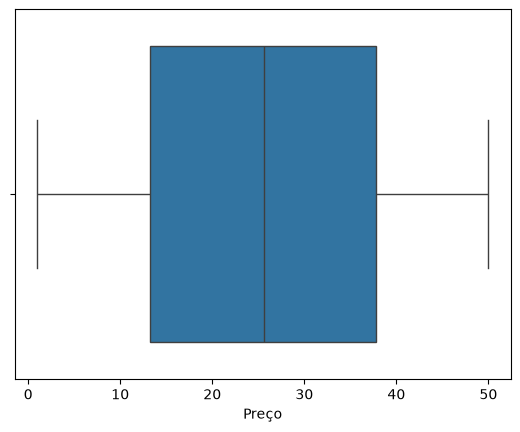

Quantidade: 0 outliers detectados


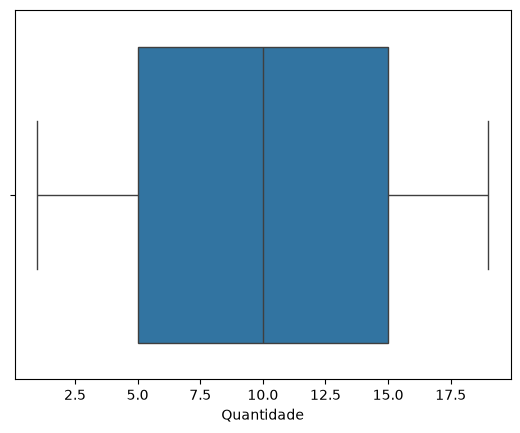

Desconto: 4180 outliers detectados


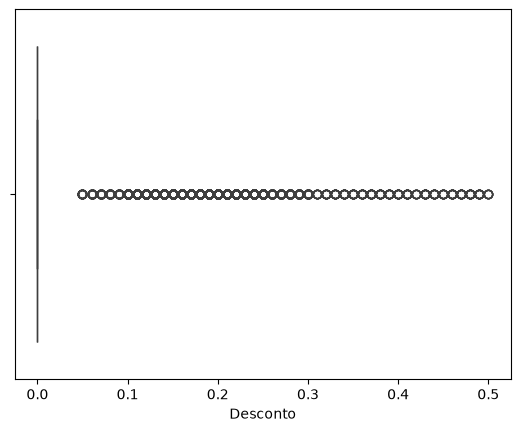

valor_total: 211 outliers detectados


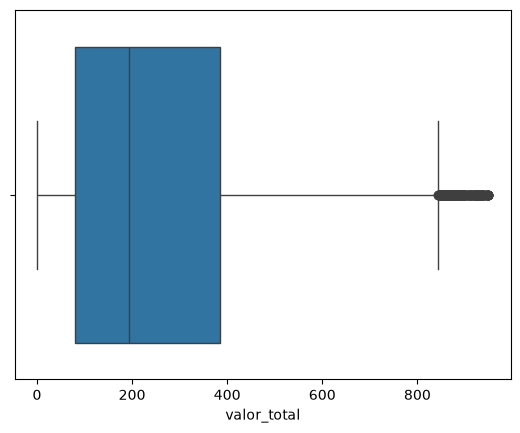

Idade: 0 outliers detectados


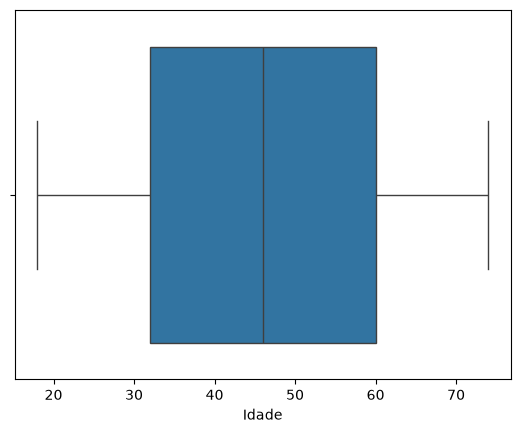

Renda: 0 outliers detectados


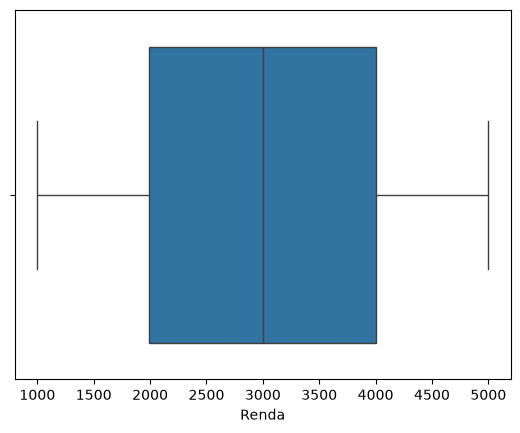

In [15]:
# Quartis e percentis
for var in variaveis:
    print(f"\nQuartis de {var}:")
    print(df[var].quantile([0.25,0.5,0.75]))
    print("Percentil 90:", df[var].quantile(0.90))

# Outliers via IQR
for var in variaveis:
    Q1 = df[var].quantile(0.25)
    Q3 = df[var].quantile(0.75)
    IQR = Q3 - Q1
    outliers = df[(df[var] < Q1 - 1.5*IQR) | (df[var] > Q3 + 1.5*IQR)]
    print(f"{var}: {len(outliers)} outliers detectados")
    sns.boxplot(x=df[var])
    plt.show()


Forma da distribuição


Distribuição de valor_total:
Assimetria (skewness): 0.9504910040627682
Curtose: 0.1105756864418681


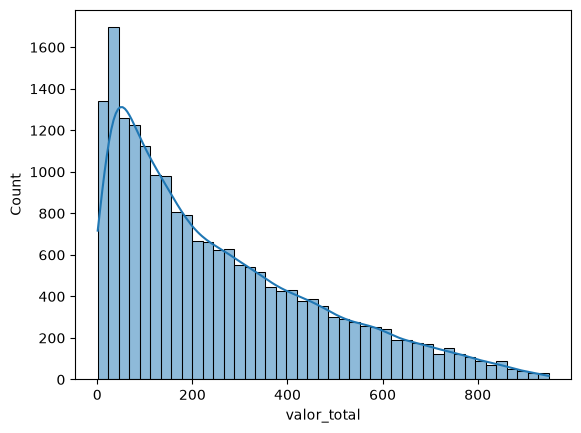


Distribuição de Idade:
Assimetria (skewness): -0.007963822160309292
Curtose: -1.2011598130621448


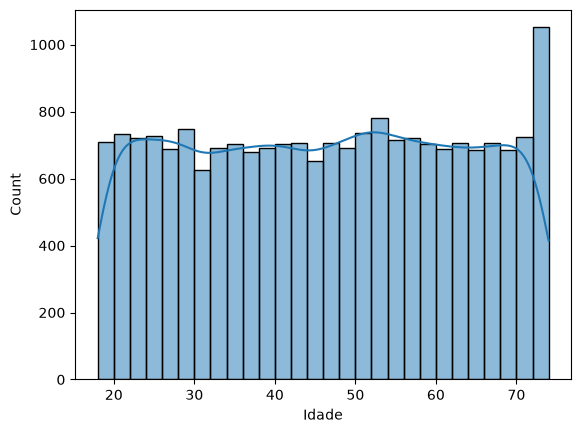

In [9]:
from scipy.stats import skew, kurtosis

for var in ["valor_total","Idade"]:
    print(f"\nDistribuição de {var}:")
    print("Assimetria (skewness):", skew(df[var]))
    print("Curtose:", kurtosis(df[var]))
    sns.histplot(df[var], kde=True)
    plt.show()

Tabelas de frequência

In [18]:
categoricas = ["Categoria","Faixa_Etaria","dia_semana","mes"]

for var in categoricas:
    print(f"\nFrequência de {var}:")
    print(df[var].value_counts())
    print(df[var].value_counts(normalize=True))


Frequência de Categoria:
Categoria
Alimentos Frescos              5475
Produtos de Mercearia          2190
Laticínios e Ovos              1825
Bebidas                        1825
Produtos de Limpeza            1825
Produtos de Higiene Pessoal    1825
Congelados                     1825
Pet Shop                       1825
Utilidades Domésticas          1460
Name: count, dtype: int64
Categoria
Alimentos Frescos              0.272727
Produtos de Mercearia          0.109091
Laticínios e Ovos              0.090909
Bebidas                        0.090909
Produtos de Limpeza            0.090909
Produtos de Higiene Pessoal    0.090909
Congelados                     0.090909
Pet Shop                       0.090909
Utilidades Domésticas          0.072727
Name: proportion, dtype: float64

Frequência de Faixa_Etaria:
Faixa_Etaria
Adulto (36-59)    8483
Jovem (18-35)     6347
Idoso (60+)       5245
Name: count, dtype: int64
Faixa_Etaria
Adulto (36-59)    0.422565
Jovem (18-35)     0.316164
Idoso (

Perguntas de negócio

<Axes: xlabel='Categoria'>

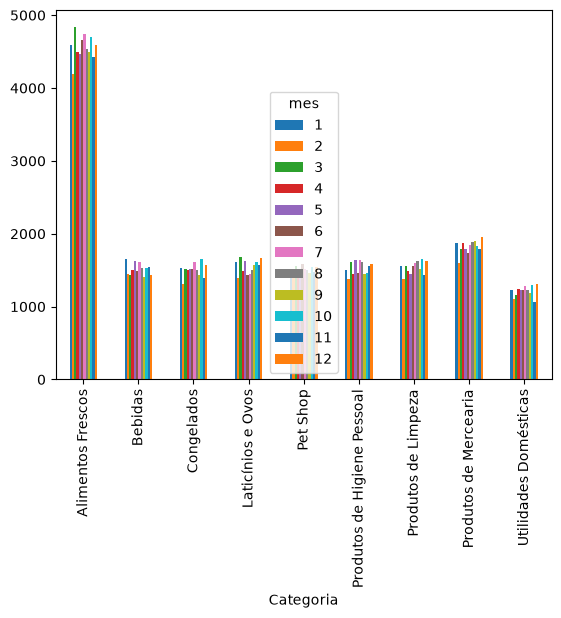

In [21]:
# 1. Categorias mais vendidas e meses de pico
df.groupby(["Categoria","mes"])["Quantidade"].sum().unstack().plot(kind="bar")

In [24]:
# 2. Impacto das promoções
promo = df[df["Desconto"]>0]
sem_promo = df[df["Desconto"]==0]
print("Média com promoção:", promo["valor_total"].mean())
print("Média sem promoção:", sem_promo["valor_total"].mean())

Média com promoção: 254.4493540669856
Média sem promoção: 256.41457061969174


In [25]:
# 3. Média de vendas diárias por categoria
df.groupby("Categoria")["valor_total"].mean()

Categoria
Alimentos Frescos              259.648904
Bebidas                        258.815474
Congelados                     250.240910
Laticínios e Ovos              261.732800
Pet Shop                       251.148734
Produtos de Higiene Pessoal    251.168537
Produtos de Limpeza            255.417529
Produtos de Mercearia          252.804644
Utilidades Domésticas          256.528568
Name: valor_total, dtype: float64

In [27]:
# 4. Sazonalidade (coeficiente de variação mensal)
cv = df.groupby(["Categoria","mes"])["Quantidade"].sum().groupby("Categoria").apply(lambda x: x.std()/x.mean())
print(cv)

Categoria
Alimentos Frescos              0.036335
Bebidas                        0.052719
Congelados                     0.061310
Laticínios e Ovos              0.061498
Pet Shop                       0.028902
Produtos de Higiene Pessoal    0.058576
Produtos de Limpeza            0.055395
Produtos de Mercearia          0.050881
Utilidades Domésticas          0.059686
Name: Quantidade, dtype: float64


In [28]:
# 5. Faixas etárias que mais contribuíram
df.groupby("Faixa_Etaria")["valor_total"].sum()

Faixa_Etaria
Adulto (36-59)    2187120.56
Idoso (60+)       1349501.03
Jovem (18-35)     1602686.31
Name: valor_total, dtype: float64

<Axes: xlabel='dia_semana'>

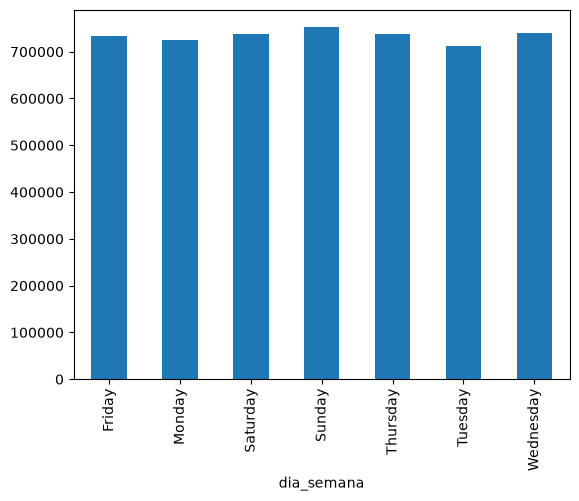

In [29]:
# 6. Distribuição por dia da semana
df.groupby("dia_semana")["valor_total"].sum().plot(kind="bar")

In [30]:
# 7. Black Friday vs meses anteriores
df.groupby("mes")["valor_total"].sum()

mes
1     436669.71
2     400993.07
3     434595.18
4     425583.78
5     423288.02
6     419441.55
7     449736.77
8     439096.97
9     406676.58
10    437387.35
11    418951.42
12    446887.50
Name: valor_total, dtype: float64

In [31]:
# 8. Ticket médio por faixa etária e categoria
df.groupby(["Faixa_Etaria","Categoria"])["valor_total"].mean()

Faixa_Etaria    Categoria                  
Adulto (36-59)  Alimentos Frescos              264.140711
                Bebidas                        250.207008
                Congelados                     253.832252
                Laticínios e Ovos              256.989066
                Pet Shop                       257.111272
                Produtos de Higiene Pessoal    255.624649
                Produtos de Limpeza            258.784335
                Produtos de Mercearia          254.445437
                Utilidades Domésticas          257.215595
Idoso (60+)     Alimentos Frescos              261.750843
                Bebidas                        270.824235
                Congelados                     250.826478
                Laticínios e Ovos              266.600125
                Pet Shop                       245.266377
                Produtos de Higiene Pessoal    249.761070
                Produtos de Limpeza            247.820665
                Produtos de 

<Axes: xlabel='Idade', ylabel='valor_total'>

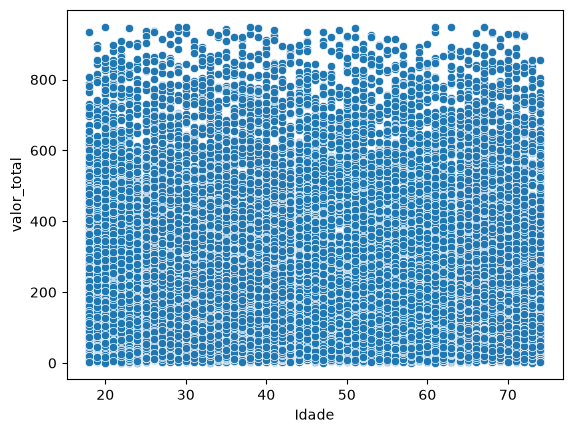

In [33]:
# 9. Relação idade × valor total
sns.scatterplot(x="Idade", y="valor_total", data=df)

In [46]:
# 10. Black Friday vs Natal
# Criar coluna semana_evento
df["semana_evento"] = "Normal"

# Definir intervalo da Black Friday
df.loc[(df["Data"].dt.month == 11) & (df["Data"].dt.day.between(20,26)), "semana_evento"] = "Black Friday"

# Definir intervalo do Natal 
df.loc[(df["Data"].dt.month == 12) & (df["Data"].dt.day.between(18,24)), "semana_evento"] = "Natal"

df.groupby("semana_evento")["valor_total"].mean()

semana_evento
Black Friday    247.186286
Natal           264.552078
Normal          256.010807
Name: valor_total, dtype: float64

Testes de Hipóteses

In [47]:
# 11. Promoções: teste t
stats.ttest_ind(promo["valor_total"], sem_promo["valor_total"])

TtestResult(statistic=np.float64(-0.5273707112505367), pvalue=np.float64(0.5979420070673219), df=np.float64(20073.0))

In [48]:
# 12. Black Friday vs Natal
bf = df[df["semana_evento"]=="Black Friday"]["valor_total"]
nat = df[df["semana_evento"]=="Natal"]["valor_total"]
stats.ttest_ind(bf, nat)

TtestResult(statistic=np.float64(-1.051633115032596), pvalue=np.float64(0.29329868262007), df=np.float64(768.0))

In [49]:
# Intervalos de confiança
ci_bf = stats.t.interval(0.95, len(bf)-1, loc=np.mean(bf), scale=stats.sem(bf))
ci_nat = stats.t.interval(0.95, len(nat)-1, loc=np.mean(nat), scale=stats.sem(nat))
print("IC Black Friday:", ci_bf)
print("IC Natal:", ci_nat)

IC Black Friday: (np.float64(224.89514789196295), np.float64(269.4774235366084))
IC Natal: (np.float64(240.94600920395635), np.float64(288.15814664019956))


In [50]:
# 13. Ticket médio geral e por faixa etária
for grupo, dados in df.groupby("Faixa_Etaria")["valor_total"]:
    ci = stats.t.interval(0.95, len(dados)-1, loc=np.mean(dados), scale=stats.sem(dados))
    print(grupo, "Média:", np.mean(dados), "IC:", ci)

Adulto (36-59) Média: 257.82394907461986 IC: (np.float64(253.22891889912887), np.float64(262.41897925011085))
Idoso (60+) Média: 257.2928560533842 IC: (np.float64(251.50046461870383), np.float64(263.0852474880645))
Jovem (18-35) Média: 252.5108413423665 IC: (np.float64(247.27852401427592), np.float64(257.74315867045703))


In [51]:
# 14. Black Friday vs mês anterior
df["mes"] = df["Data"].dt.month
mes_bf = df[df["mes"]==11]["valor_total"]
mes_ant = df[df["mes"]==10]["valor_total"]
stats.ttest_ind(mes_bf, mes_ant)

TtestResult(statistic=np.float64(-0.34875621901778775), pvalue=np.float64(0.7272942314350223), df=np.float64(3353.0))